# Week 2 — Exploratory Data Analysis with Insights
**VortexTech Data Science & Analytics Internship Track**

**Objective:** Go beyond basic charts and conduct a structured EDA, finding and clearly explaining 3 meaningful patterns/relationships in the data.

**Dataset:** The classic `tips` dataset (244 rows) — records of restaurant bills, tips, and details about the table (party size, day, time, smoker status, sex of the bill-payer). It has a good mix of numeric columns (`total_bill`, `tip`, `size`) and categorical columns (`sex`, `smoker`, `day`, `time`), making it well suited for correlation and group-comparison analysis.


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

df = sns.load_dataset("tips")
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## 1. Quick Recap Clean
Even though this dataset is generally tidy, we start every analysis with the same checks: missing values, duplicate rows, and correct data types.

In [2]:
print("Shape:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (244, 7)

Data types:
 total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

Missing values per column:
 total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

Duplicate rows: 1


**Findings:** No missing values, and the categorical columns (`sex`, `smoker`, `day`, `time`) are already typed as `category`. There is 1 duplicate row, which we drop below so it doesn't skew our statistics.

In [3]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Shape after dropping duplicates: (243, 7)


We also engineer one helpful derived column, `tip_pct` (tip as a % of the bill), since raw tip amount is partly just a function of bill size — the *percentage* tells us more about generosity.

In [4]:
df["tip_pct"] = df["tip"] / df["total_bill"] * 100
df.head()

,total_bill,tip,sex,smoker,day,time,size,tip_pct
0,16.99,1.01,Female,No,Sun,Dinner,2,5.944673
1,10.34,1.66,Male,No,Sun,Dinner,3,16.054159
2,21.01,3.50,Male,No,Sun,Dinner,3,16.658734
3,23.68,3.31,Male,No,Sun,Dinner,2,13.978041
4,24.59,3.61,Female,No,Sun,Dinner,4,14.680765


## 2. Correlation Heatmap
We generate a correlation matrix for the numeric columns and visualize it as a heatmap to spot the strongest relationships at a glance.

In [5]:
numeric_cols = df.select_dtypes(include="number").drop(columns=["tip_pct"])
corr = numeric_cols.corr()
corr

,total_bill,tip,size
total_bill,1.000000,0.674998,0.597589
tip,0.674998,1.000000,0.488400
size,0.597589,0.488400,1.000000


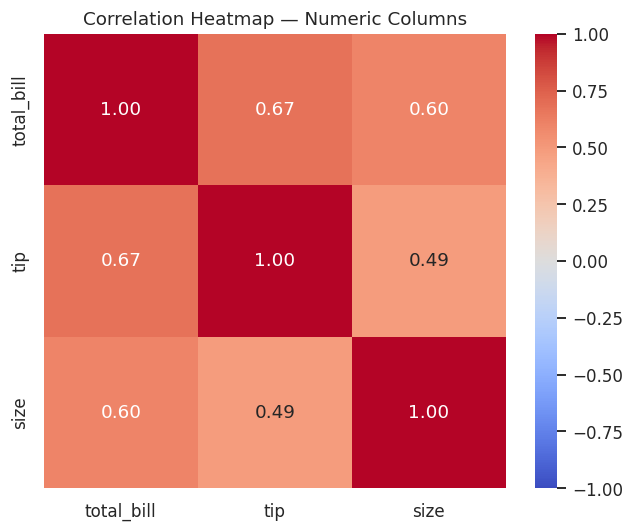

In [6]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation Heatmap — Numeric Columns")
plt.tight_layout()
plt.show()

**Reading the heatmap:** the two strongest relationships among the numeric columns are:
1. `total_bill` ↔ `tip` (r ≈ 0.68)
2. `total_bill` ↔ `size` (r ≈ 0.60)

We visualize both with scatter plots below.

## 3. Relationship 1 — Total Bill vs. Tip

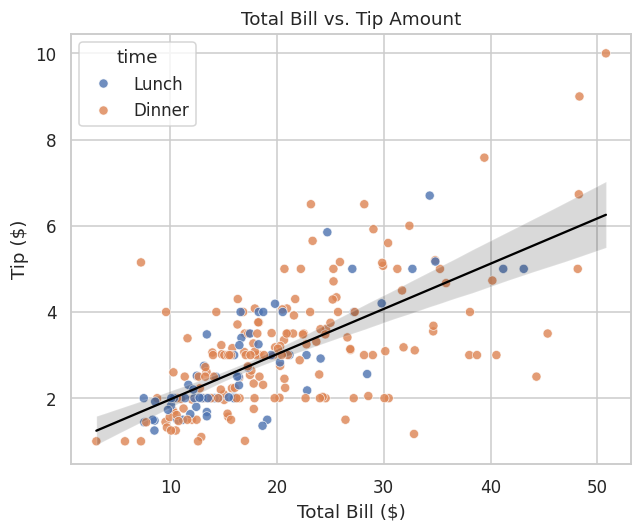

In [7]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="total_bill", y="tip", hue="time", alpha=0.8)
sns.regplot(data=df, x="total_bill", y="tip", scatter=False, color="black", line_kws={"linewidth": 1.5})
plt.title("Total Bill vs. Tip Amount")
plt.xlabel("Total Bill ($)")
plt.ylabel("Tip ($)")
plt.tight_layout()
plt.show()

## 4. Relationship 2 — Total Bill vs. Party Size

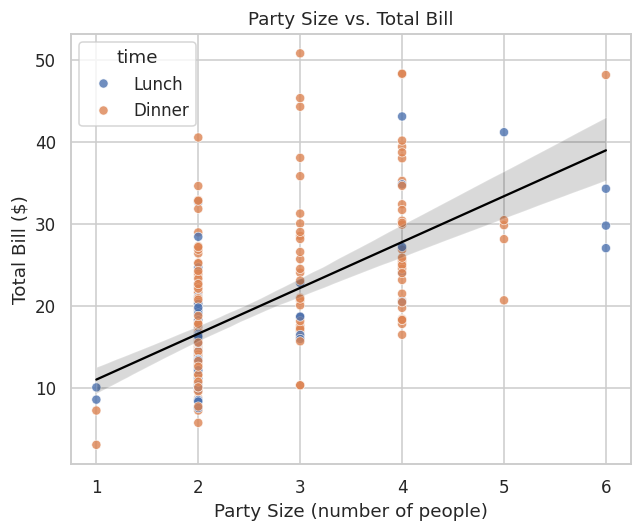

In [8]:
plt.figure(figsize=(6, 5))
sns.scatterplot(data=df, x="size", y="total_bill", hue="time", alpha=0.8)
sns.regplot(data=df, x="size", y="total_bill", scatter=False, color="black", line_kws={"linewidth": 1.5})
plt.title("Party Size vs. Total Bill")
plt.xlabel("Party Size (number of people)")
plt.ylabel("Total Bill ($)")
plt.tight_layout()
plt.show()

## 5. Categorical Relationship — Average Bill by Day of Week

In [9]:
day_avg = df.groupby("day", observed=True)["total_bill"].mean().sort_values(ascending=False)
day_avg

day
Sun     21.410000
Sat     20.441379
Thur    17.759508
Fri     17.151579
Name: total_bill, dtype: float64

/tmp/ipykernel_142/693692648.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_avg.index, y=day_avg.values, order=day_avg.index, palette="coolwarm")


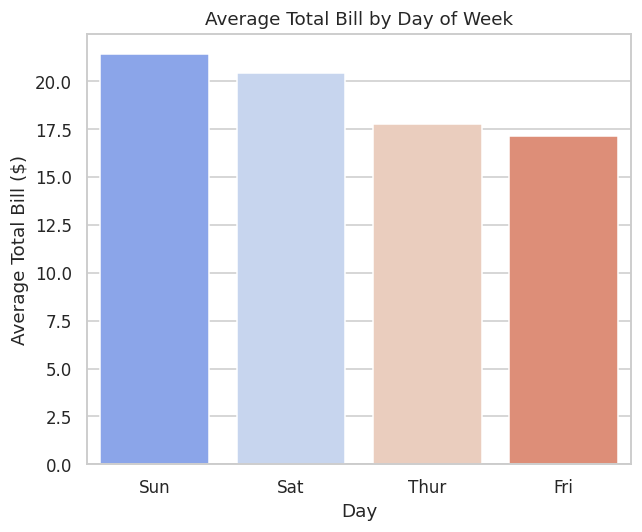

In [10]:
plt.figure(figsize=(6, 5))
sns.barplot(x=day_avg.index, y=day_avg.values, order=day_avg.index, palette="coolwarm")
plt.title("Average Total Bill by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Total Bill ($)")
plt.tight_layout()
plt.show()

## 6. Key Insights — Conclusion

**Insight 1 — Bigger bills mean bigger tips, and fairly predictably.**
`total_bill` and `tip` have a correlation of **r ≈ 0.68**, the strongest relationship in the dataset. The scatter plot shows a clear upward trend: for every extra $10 on the bill, the tip rises by roughly $1, consistent with people tipping a rough percentage of the bill rather than a flat amount.

**Insight 2 — Larger parties spend more in total, but not proportionally more per person.**
`total_bill` and `size` correlate at **r ≈ 0.60**. Bills do rise with party size, but the scatter plot shows the relationship flattening out for parties of 5–6 — the per-person cost of dining actually *drops* as groups get bigger (shared appetizers, less individual ordering), so total spend grows sub-linearly with headcount.

**Insight 3 — Sunday bills run about 25% higher than Thursday/Friday bills.**
Grouping by day, Sunday has the highest average bill (~$21.4) while Friday has the lowest (~$17.2) — a **~25% difference**. This likely reflects the difference between leisurely weekend family/group dining (larger parties, more courses) versus quicker weekday lunches, which is also consistent with `size` correlating positively with `total_bill` from Insight 2.

### Overall
The data tells a coherent story: bill size drives tip size, larger groups drive up total spend (with diminishing per-person cost), and weekend dining patterns push bills higher than weekday ones — most likely because Sunday visits skew toward larger, longer group meals rather than quick individual lunches.
